# DECODE - Fit SMLM Data
The purpose of this notebook is to demonstrate the fitting procedure for a pretrained model.
Please be advised to have a read of the Introduction notebook first.

Notebook has been modified for data from Janelia Hess Lab PALM instrument. 

In [2]:
import sys

import decode
import decode.utils

import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import yaml
import os
from wip_util import zero_pad_index

print(f"DECODE version: {decode.utils.bookkeeping.decode_state()}")

c:\Users\bnort\miniconda3\envs\decode_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


DECODE version: v0.10.2-3-ga90adbc-dirty


## Specify paths for the frames and the results

In [5]:
# here you need to specify the parameters with suffix _run.yaml in your model's output folder (not param_run_in.yaml)

frame_path = r'E:\Cryo-PALM Data for Brian\James processing ASCII and RAW Data files\PALM_Run2_slab_0001_488nm_Frames_(Processed_Slab)'
out_path = r'D:\Janelia_slm_data\processed\Janelia PALM RUN2'
fig_path = os.path.join(out_path, 'figures-2025-06-03')
out_iter_path = os.path.join(out_path, 'processed-2025-06-17')
param_path = r'D:\Janelia_slm_data\models\network_CMOS_C13440_20CU\2025-05-01-d\params.yaml'

if not os.path.exists(out_iter_path):
    os.makedirs(out_iter_path)

if not os.path.exists(out_path):
    os.makedirs(out_path)

if not os.path.exists(fig_path):
    os.makedirs(fig_path)

## Load Parameters and Model
Specify Post-Processing as by the parameter file you trained the model with

In [6]:
param = decode.utils.param_io.load_params(param_path)

## Load and Process Frames
Load TIFF file.
Change only needed if you load a custom tif file.
Note that the TIFF loader will auto-load and concatenate tiff files
that are consecutive and share
the same meta data. For example specifying `dummy.tif` will also load  `dummy_0.tif, dummy_1.tif` if present in the
same folder.
If you have single page tiff files, you can also specify a folder.

In [7]:
from skimage.io import imread
import glob
from tqdm import tqdm

frames_per_iter = 250
start_iter = 230 
end_iter = 250

In [8]:
def get_frames_name(id):
    return rf'{frame_path}\3dpalm488nm_iter_{zero_pad_index(id, 4)}_0001_ch0_cam1_stack0000_405nm_0000000msec_*msecabs_000x_000y_000z_0001t.tif'

def load_frames(id):
    #print(f"loading frames for id: {id}")
    frames_pattern = rf'{frame_path}\3dpalm488nm_iter_{zero_pad_index(id, 4)}_0001_ch0_cam1_stack0000_405nm_0000000msec_*msecabs_000x_000y_000z_0001t.tif'
    frames_name = glob.glob(frames_pattern)
    if frames_name:
        return imread(frames_name[0])
    else:
        print(f"no frames found for id: {id}")
        return None

# get a single 'iter' used for setting up the model
frames = np.concatenate([load_frames(i) for i in tqdm(range(0, 1))], axis=0)
frames = imread(get_frames_name(0)) 
print(f"Loaded frames shape: {frames.shape}")

100%|██████████| 1/1 [00:06<00:00,  6.64s/it]


Loaded frames shape: (250, 800, 800)


In [9]:

camera = decode.simulation.camera.Photon2Camera.parse(param)
camera.device = 'cpu'


Frames shape: (250, 800, 800)


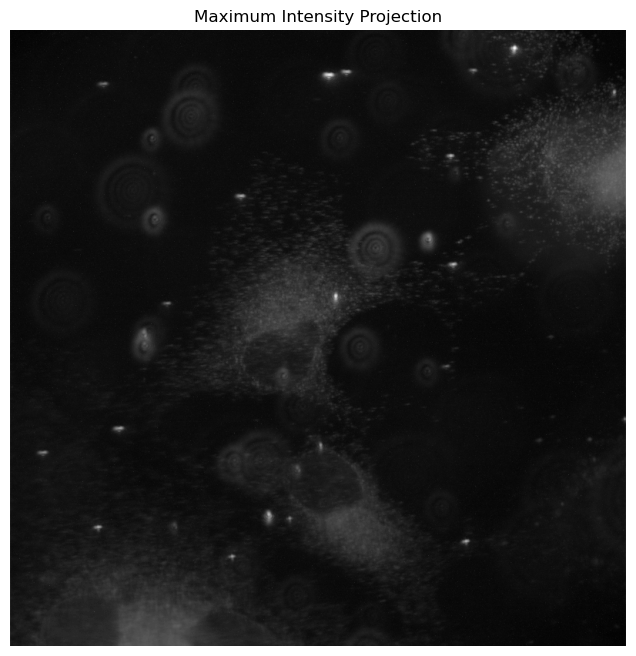

In [10]:

transpose_frames = False 
## switch x and y axis to be consistent with SMAP??  TODO: Look into this further and make sure image is still consistent with calibration....
if transpose_frames:
    frames = frames.transpose(0, 2, 1)

print(f"Frames shape: {frames.shape}")


# Compute maximum intensity projection (MIP)
max_projection = np.log1p(np.max(frames, axis=0))  # Collapse along depth
# Display the MIP using matplotlib
plt.figure(figsize=(8, 8))
plt.imshow(max_projection, cmap='gray')
plt.axis("off")
plt.title("Maximum Intensity Projection")
plt.show()


In [12]:
device = 'cuda:0'  # or 'cpu', or you change cuda device index

#  create a small reference set of frames that is used to get sizes from in some calls
frames_ = torch.tensor(frames[:10].astype('float32'), dtype=torch.float32, device=device)
frames_.shape
frames_[0]

tensor([[144., 141., 134.,  ..., 142., 167., 150.],
        [154., 139., 129.,  ..., 138., 124., 145.],
        [142., 138., 142.,  ..., 144., 155., 145.],
        ...,
        [281., 204., 193.,  ..., 143., 137., 160.],
        [288., 229., 188.,  ..., 135., 143., 169.],
        [286., 185., 206.,  ..., 139., 135., 157.]], device='cuda:0')

## Set Up Pre- and Post-Processing
In the following we will set up the processing pipeline.

### Frame-Processing
**WARNING: Mirror2D** Depending on your specific camera setup you need to modify the following pipeline. In our case (using an EM-CCD camera) the beads are acquired without EM-Gain, while the experimental frames were acquired with EM-Gain. For our camera, due to some hardware specifics, EM-Gain enabled will lead the frames to be mirrored in the last dimension. Since the trained model and the experimental frames need to be consistent with respect to the PSF, we account for this mirroring by `Mirror2D(dims=-1)`.

Depending on your individual camera you might be able to omit this. Particularly if you are using a sCMOS camera.

**AutoCenterCrop** Due to peculiarities of training a Deep Learning model, the size of the input frame is slightly restricted. In our case the input frame size must be in multitudes of 8 per edge. For this reason we ***center crop*** the frame to a size that satisfies this requirement. That means an input frame of size 34 x 41 would be cropped to 32 x 40 and only fitted in this region. If you want to use a non-destructive method you could replace `AutoCenterCrop` by `AutoPad`, however this could lead to a distortion at the frame border which is why we recommend `AutoCenterCrop`.

In [13]:
# setup frame processing as by the parameter with which the model was trained
frame_proc = decode.neuralfitter.utils.processing.TransformSequence([
    decode.neuralfitter.utils.processing.wrap_callable(camera.backward),
    decode.neuralfitter.frame_processing.AutoCenterCrop(8),
    decode.neuralfitter.frame_processing.Mirror2D(dims=-1),  # WARNING: You might need to comment this line out. see above
    decode.neuralfitter.scale_transform.AmplitudeRescale.parse(param)
])

# determine extent of frame and its dimension after frame_processing
size_procced = decode.neuralfitter.frame_processing.get_frame_extent(frames_.unsqueeze(1).size(), frame_proc.forward)  # frame size after processing
frame_extent = ((-0.5, size_procced[-2] - 0.5), (-0.5, size_procced[-1] - 0.5))


# Setup post-processing
# It's a sequence of backscaling, relative to abs. coord conversion and frame2emitter conversion
post_proc = decode.neuralfitter.utils.processing.TransformSequence([

    decode.neuralfitter.scale_transform.InverseParamListRescale.parse(param),

    decode.neuralfitter.coord_transform.Offset2Coordinate(xextent=frame_extent[0],
                                                          yextent=frame_extent[1],
                                                          img_shape=size_procced[-2:]),

    decode.neuralfitter.post_processing.SpatialIntegration(raw_th=0.1,
                                                          xy_unit='px',
                                                          px_size=param.Camera.px_size)


])

c:\Users\bnort\miniconda3\envs\decode_env\lib\site-packages\torch\functional.py:478: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at  C:\cb\pytorch_1000000000000\work\aten\src\ATen\native\TensorShape.cpp:2895.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


## Load the Data

In [25]:

load = True 

# create empty emitter set for loading
emitter = None
if load:
    for i in tqdm(range(start_iter, end_iter), desc="Loading iterations"):
        out_h5 = os.path.join(out_iter_path, f'iter_{i}.h5')
        #print(i, start_iter, end_iter)
        if emitter is None:
            emitter = decode.EmitterSet.load(out_h5)
            emitter.frame_ix += i * frames_per_iter
        else:
            emitter_ = decode.EmitterSet.load(out_h5)
            emitter_.frame_ix += i * frames_per_iter
            emitter = decode.EmitterSet.cat([emitter, emitter_])

Loading iterations: 100%|██████████| 20/20 [00:00<00:00, 25.58it/s]


In [15]:
print(f"Total emitters loaded: {len(emitter)}")

emitter.frame_ix

Total emitters loaded: 3466320


tensor([57500, 57500, 57500,  ..., 62499, 62499, 62499])

In [26]:
print(emitter)
sigma_x_high_threshold = 2000 
sigma_y_high_threshold = 2000
sigma_z_high_threshold = 10000
prob_threshold = 0.0
coord_limit=((500,700),(100,200))
coord_limit=((0,500),(0,700))

print("0,1", coord_limit[0][0], coord_limit[0][1])

emitter = emitter[
    (emitter.xyz_sig_nm[:, 0] <= sigma_x_high_threshold)
    * (emitter.xyz_sig_nm[:, 1] <= sigma_x_high_threshold)
    * (emitter.xyz_sig_nm[:, 2] <= sigma_z_high_threshold)
    * (emitter.prob >= prob_threshold)
    ]

print(emitter)



EmitterSet
::num emitters: 3466320
::xy unit: px
::px size: tensor([130., 130.])
::frame range: 57500 - 62499
::spanned volume: [-4.0179032e-01 -1.0818105e-01 -1.1996052e+03] - [ 799.3804  798.9981 1200.    ]
0,1 0 500
EmitterSet
::num emitters: 3466320
::xy unit: px
::px size: tensor([130., 130.])
::frame range: 57500 - 62499
::spanned volume: [-4.0179032e-01 -1.0818105e-01 -1.1996052e+03] - [ 799.3804  798.9981 1200.    ]


In [10]:
out_csv = os.path.join(out_path, f'emitters_{start_iter}_{end_iter}_filtered.csv')
print(out_csv)
emitter.save(out_csv)

D:\Janelia_slm_data\processed\Janelia PALM RUN2\emitters_100_230_filtered.csv


You can check if the predictions look reasonable on a random frame

In [19]:
frames_.shape, frames.shape

(torch.Size([10, 800, 800]), (250, 800, 800))

random_ix: 50
frame_num: 57550
EmitterSet
::num emitters: 165
::xy unit: px
::px size: tensor([130., 130.])
::frame range: 57550 - 57550
::spanned volume: [ 1.9744743e+01  6.6757202e-06 -9.7827087e+02] - [724.54016 758.549   996.5232 ]


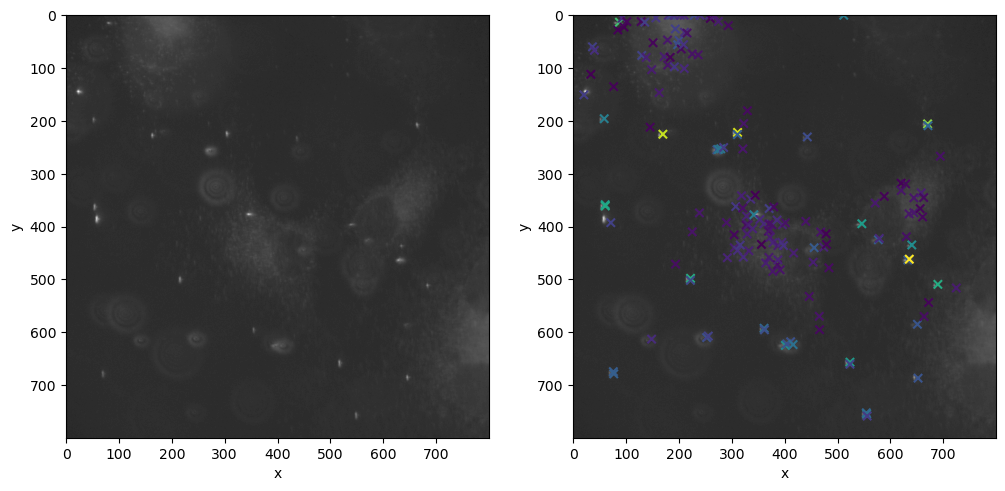

In [20]:
random_ix = 50 #start_iter*frames_per_iter+torch.randint(frames_.size(0), size=(1, )).item()
frame_num = start_iter*frames_per_iter + random_ix
print(f"random_ix: {random_ix}")
print(f"frame_num: {frame_num}")

em_subset = emitter.get_subset_frame(frame_num, frame_num)
print(em_subset)

# convert frames to tensor
frames_ = torch.tensor(frames.astype('float32'), dtype=torch.float32, device=device)

plt.figure(figsize=(12, 6))
plt.subplot(121)
decode.plot.PlotFrameCoord(frame=frame_proc.forward(frames_[[random_ix]])).plot()

plt.subplot(122)
decode.plot.PlotFrameCoord(frame=frame_proc.forward(frames_[[random_ix]]),
                           pos_out=em_subset.xyz_px, phot_out=em_subset.phot).plot()

plt.savefig(os.path.join(fig_path, rf'emitter_frame{random_ix}.png'), dpi=300, bbox_inches='tight')
plt.show()

Here we compare the inferred distribution of the photon numbers and background values with the ranges used during training.
If the inferred values fall outside of the green regions, or are concentrated in a small subspace of it, it might make sense to adjust the simulation parameters and retrain the the network.

C:\Users\bnort\AppData\Local\Temp\ipykernel_12936\2509081767.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(emitter.phot.numpy())
C:\Users\bnort\AppData\Local\Temp\ipykernel_12936\2509081767.py:12: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(emitter.bg.numpy())


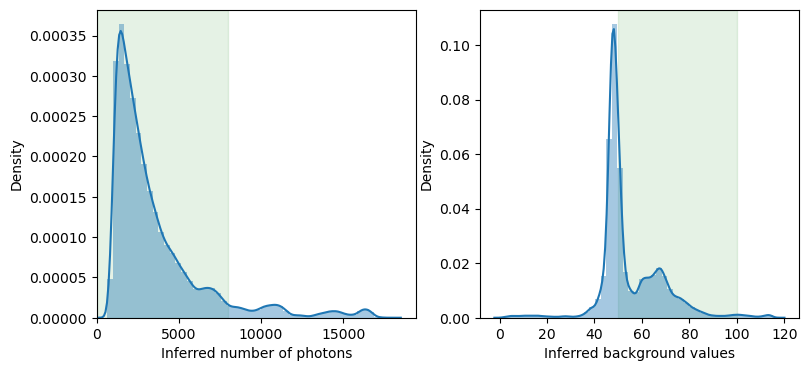

In [21]:
plt.figure(figsize=(14, 4))

plt.subplot(131)
mu, sig = param.Simulation.intensity_mu_sig
plt.axvspan(0, mu + sig * 3, color='green', alpha=0.1)
sns.distplot(emitter.phot.numpy())
plt.xlabel('Inferred number of photons')
plt.xlim(0)

plt.subplot(132)
plt.axvspan(*param.Simulation.bg_uniform, color='green', alpha=0.1)
sns.distplot(emitter.bg.numpy())
plt.xlabel('Inferred background values')

plt.show()

## Postprocessing

Plot X, Y and Z distribution.  (Seems like too many at the lower z range)

C:\Users\bnort\AppData\Local\Temp\ipykernel_12936\2027465624.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(emitter.xyz_nm[:, 0].numpy())
C:\Users\bnort\AppData\Local\Temp\ipykernel_12936\2027465624.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(emitter.xyz_nm[:, 1].numpy())
C:\Users\b

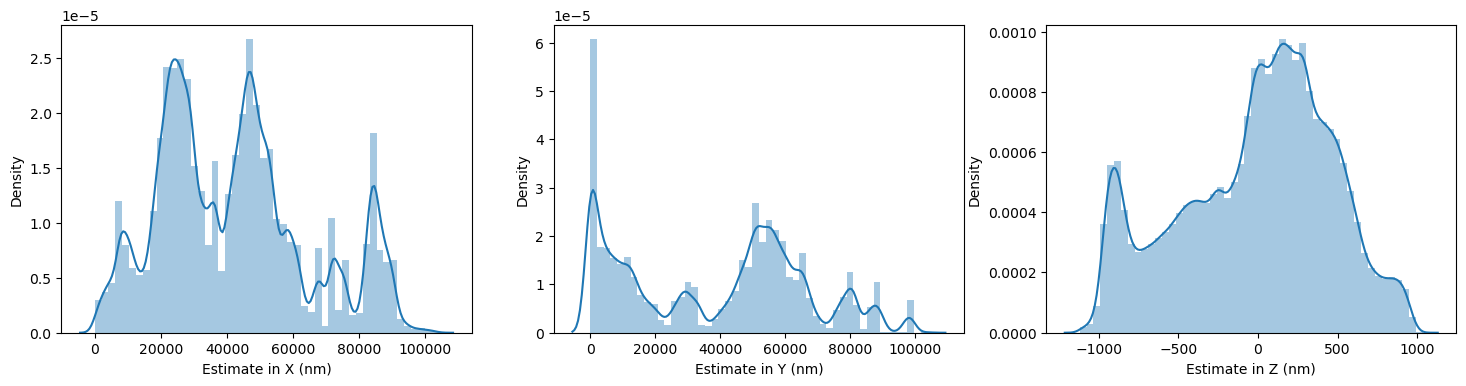

In [22]:
plt.figure(figsize=(18,4))
plt.subplot(131)
sns.distplot(emitter.xyz_nm[:, 0].numpy())
plt.xlabel('Estimate in X (nm)')

plt.subplot(132)
sns.distplot(emitter.xyz_nm[:, 1].numpy())
plt.xlabel('Estimate in Y (nm)')

plt.subplot(133)
sns.distplot(emitter.xyz_nm[:, 2].numpy())
plt.xlabel('Estimate in Z (nm)')

plt.show()

DECODE will in general detect very high numbers of emitters, including those with high uncertainties.
Fortunately every DECODE prediction includes uncertainty estimates in x,y and z which we plot here.

C:\Users\bnort\AppData\Local\Temp\ipykernel_26192\2191060794.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(emitter.xyz_sig_nm[:, 0].numpy())
C:\Users\bnort\AppData\Local\Temp\ipykernel_26192\2191060794.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(emitter.xyz_sig_nm[:, 1].numpy())
C:

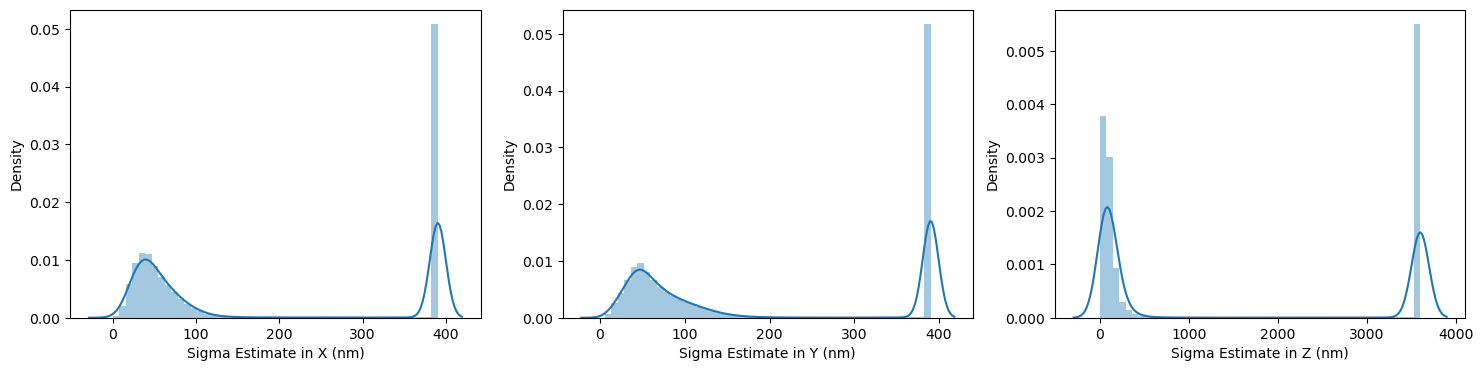

In [ ]:
plt.figure(figsize=(18,4))
plt.subplot(131)
sns.distplot(emitter.xyz_sig_nm[:, 0].numpy())
plt.xlabel('Sigma Estimate in X (nm)')

plt.subplot(132)
sns.distplot(emitter.xyz_sig_nm[:, 1].numpy())
plt.xlabel('Sigma Estimate in Y (nm)')

plt.subplot(133)
sns.distplot(emitter.xyz_sig_nm[:, 2].numpy())
plt.xlabel('Sigma Estimate in Z (nm)')


plt.show()

Plot the probability

In [37]:
emitter.prob.min(), emitter.prob.max()

(tensor(0.7500), tensor(1.))

C:\Users\bnort\AppData\Local\Temp\ipykernel_12936\4167075777.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(emitter.prob.numpy())


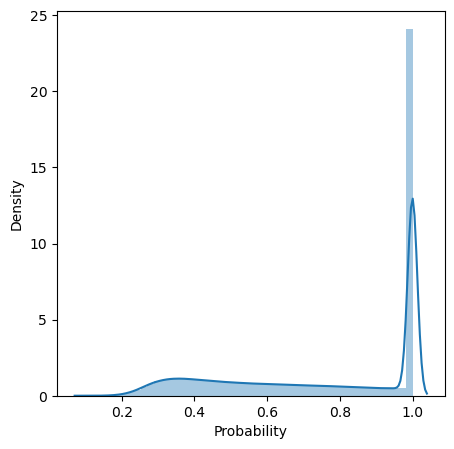

In [27]:
plt.figure(figsize=(5,5))
sns.distplot(emitter.prob.numpy())
plt.xlabel('Probability')

plt.show()

See how emitter count changes as a function of frame

C:\Users\bnort\AppData\Local\Temp\ipykernel_16044\3960185180.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(emitter.frame_ix.numpy())


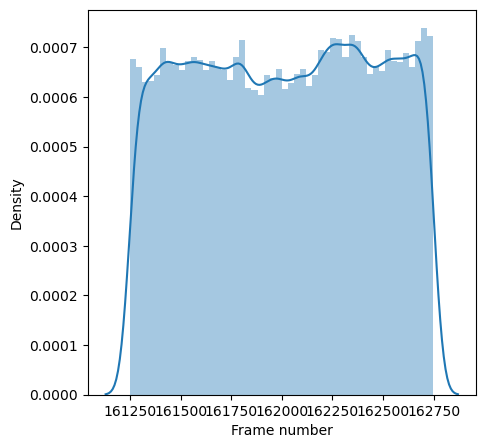

In [39]:
plt.figure(figsize=(5,5))
sns.distplot(emitter.frame_ix.numpy())
plt.xlabel('Frame number')

plt.show()

C:\Users\bnort\AppData\Local\Temp\ipykernel_16044\3233242160.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(em_subset.xyz_sig_weighted_tot_nm.numpy())


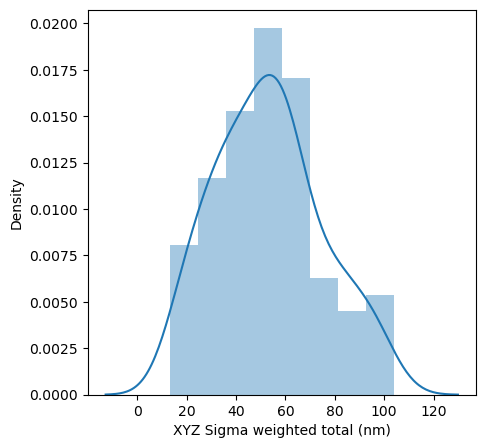

In [40]:
plt.figure(figsize=(5,5))
sns.distplot(em_subset.xyz_sig_weighted_tot_nm.numpy())
plt.xlabel('XYZ Sigma weighted total (nm)')

plt.show()

## Render

We provide a simple histogram rendering procedure for initial evaluation. You can specify the pixel size in nm, the sigma value for a Gaussian blur, and a clipping value and contrast to control the brightness.
The histogram takes an Emitterset as input, and optionally also a vector of the same length which adds a color dimension.
Below we plot the x-y view with z as colordimension as well as the x-z view.
On the right side we instead color by the combined inferred uncertainty. This highlights some artifacts (red spots) and how the uncertainty is driven by the z location and the density.

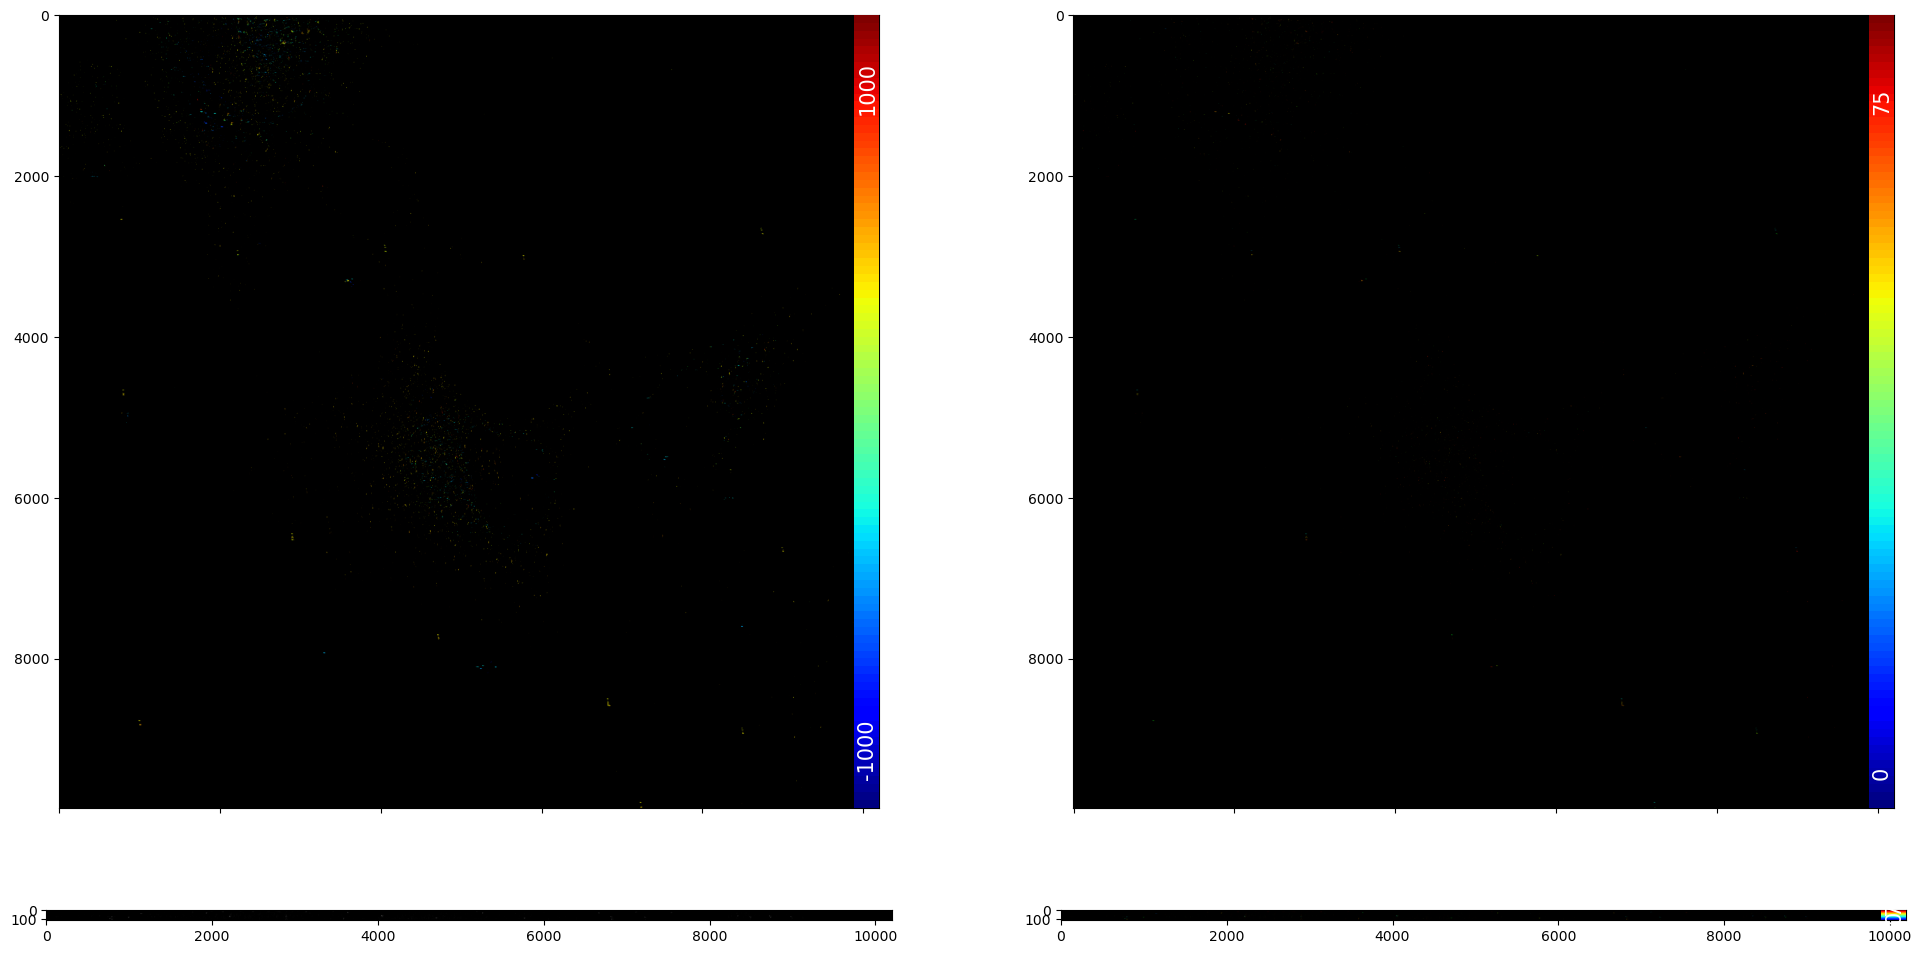

In [ ]:
fig, axs = plt.subplots(2, 2, figsize=(24, 12), sharex='col',
                        gridspec_kw={'height_ratios': [1, 1200 / 20000]})

decode.renderer.Renderer2D(px_size=10., sigma_blur=5., rel_clip=None, abs_clip=5,
                           zextent=[-1000, 1000], colextent=[-1000, 1000], plot_axis=(0, 1),
                           contrast=15.25).render(emitter, emitter.xyz_nm[:, 2], ax=axs[0, 0])

 
decode.renderer.Renderer2D(px_size=10., sigma_blur=5., rel_clip=None, abs_clip=50,
                           zextent=[-600, 600], plot_axis=(0, 2)).render(emitter, ax=axs[1, 0])

decode.renderer.Renderer2D(px_size=10., sigma_blur=5., rel_clip=None, abs_clip=5,
                           zextent=[-600, 600], colextent=[0, 75], plot_axis=(0, 1),
                           contrast=1.25).render(emitter, emitter.xyz_sig_weighted_tot_nm, ax=axs[0, 1])

decode.renderer.Renderer2D(px_size=10., sigma_blur=5., rel_clip=None, abs_clip=50,
                           zextent=[-600, 600], colextent=[0, 75], plot_axis=(0, 2)).\
    render(emitter, emitter.xyz_sig_weighted_tot_nm, ax=axs[1, 1])

plt.savefig(os.path.join(fig_path, rf'rendered.png'), dpi=300, bbox_inches='tight')
plt.show()

Plot an ROI of a frame to take a closer look at emitter positions. 

0,1 0 500
EmitterSet
::num emitters: 94
::xy unit: px
::px size: tensor([130., 130.])
::frame range: 161253 - 161253
::spanned volume: [ 4.3234051e+01  2.9385090e-05 -9.8667395e+02] - [692.943   757.1224  907.33746]


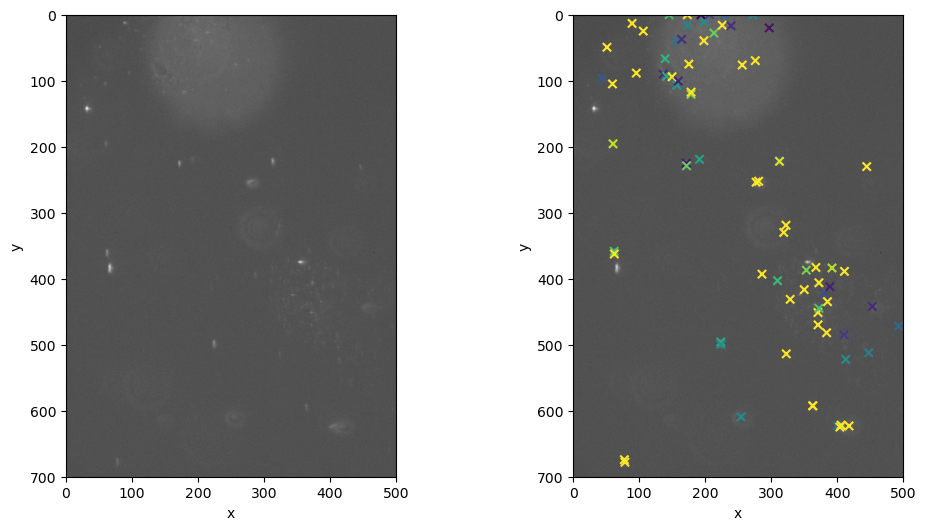

In [26]:
random_ix = 3 #torch.randint(frames_.size(0), size=(1, )).item()
frame_num = start_iter*frames_per_iter + random_ix

sigma_x_high_threshold = 100
sigma_y_high_threshold = 100
sigma_z_high_threshold = 200
prob_threshold = 0.79
coord_limit=((500,700),(100,200))
coord_limit=((0,500),(0,700))

print("0,1", coord_limit[0][0], coord_limit[0][1])
em_subset = emitter.get_subset_frame(frame_num, frame_num)

em_subset = em_subset[
    (em_subset.xyz_sig_nm[:, 0] <= sigma_x_high_threshold)
    * (em_subset.xyz_sig_nm[:, 1] <= sigma_x_high_threshold)
    * (em_subset.xyz_sig_nm[:, 2] <= sigma_z_high_threshold)
    * (em_subset.prob >= prob_threshold)
    ]

print(em_subset)

plt.figure(figsize=(12, 6))
plt.subplot(121)

decode.plot.PlotFrameCoord(frame=frame_proc.forward(frames_[[random_ix]]), coord_limit=coord_limit).plot()

plt.subplot(122)
decode.plot.PlotFrameCoord(frame=frame_proc.forward(frames_[[random_ix]]),
                           pos_out=em_subset.xyz_px, phot_out=em_subset.prob, coord_limit=coord_limit).plot()
plt.show()

If we want to visualize a sub-range with ```Renderer2D.plot``` we need to enter the x and/or yextend in physical units (pixels*spacings).  Here we visualize a ```yextent``` from 10000 to 20000 nm. 

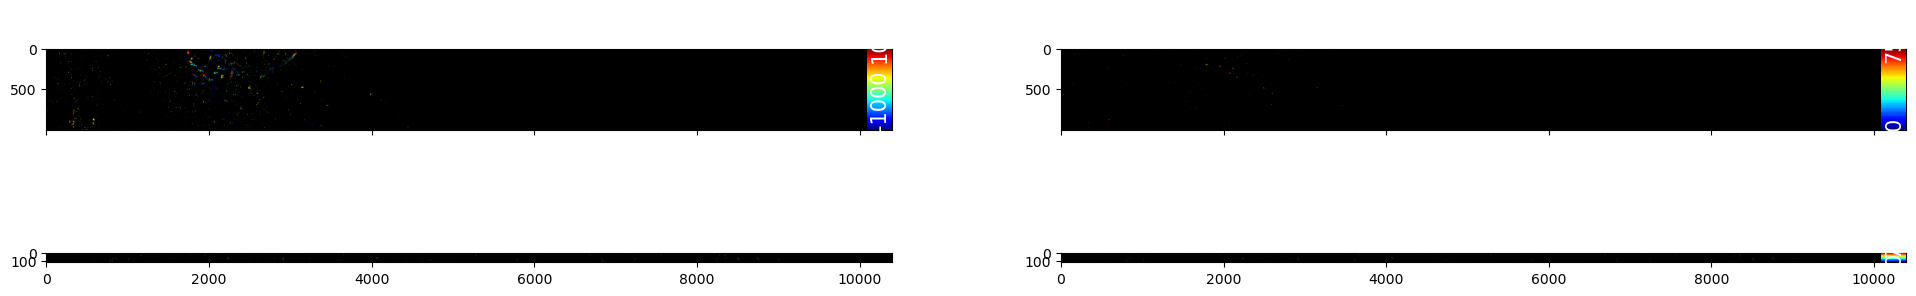

In [27]:
fig, axs = plt.subplots(2, 2, figsize=(24, 4), sharex='col',
                        gridspec_kw={'height_ratios': [1, 1200 / 20000]})

decode.renderer.Renderer2D(px_size=10., sigma_blur=5., rel_clip=None, abs_clip=5, yextent=[10000, 20000],
                           zextent=[-1000, 1000], colextent=[-1000, 1000], plot_axis=(0, 1),
                           contrast=15.25).render(emitter, emitter.xyz_nm[:, 2], ax=axs[0, 0])
decode.renderer.Renderer2D(px_size=10., sigma_blur=5., rel_clip=None, abs_clip=50,
                           zextent=[-600, 600], plot_axis=(0, 2)).render(emitter, ax=axs[1, 0])

decode.renderer.Renderer2D(px_size=10., sigma_blur=5., rel_clip=None, abs_clip=5, yextent=[10000, 20000],
                           zextent=[-600, 600], colextent=[0, 75], plot_axis=(0, 1),
                           contrast=1.25).render(emitter, emitter.xyz_sig_weighted_tot_nm, ax=axs[0, 1])

decode.renderer.Renderer2D(px_size=10., sigma_blur=5., rel_clip=None, abs_clip=50,
                           zextent=[-600, 600], colextent=[0, 75], plot_axis=(0, 2)).\
    render(emitter, emitter.xyz_sig_weighted_tot_nm, ax=axs[1, 1])

plt.show()

It is almost always beneficial for the image quality to remove the worst localizations.
Below we remove all localizations with uncertainties that exceed 40 nm in x,y or 80 nm in z.
This leaves us with a lower percentage of the detections. Alternatively you can specify the remaining percentage directly with the `emitter.filter_by_sigma(fraction)` method which will remove the emitters with the lowest combined uncertainty.
If you compare the rendering to the previous (unfiltered) one, you can see that this procedure eliminated all visible artefacts. However it also removed out of focus tubules in the top right corner that where previously visible.

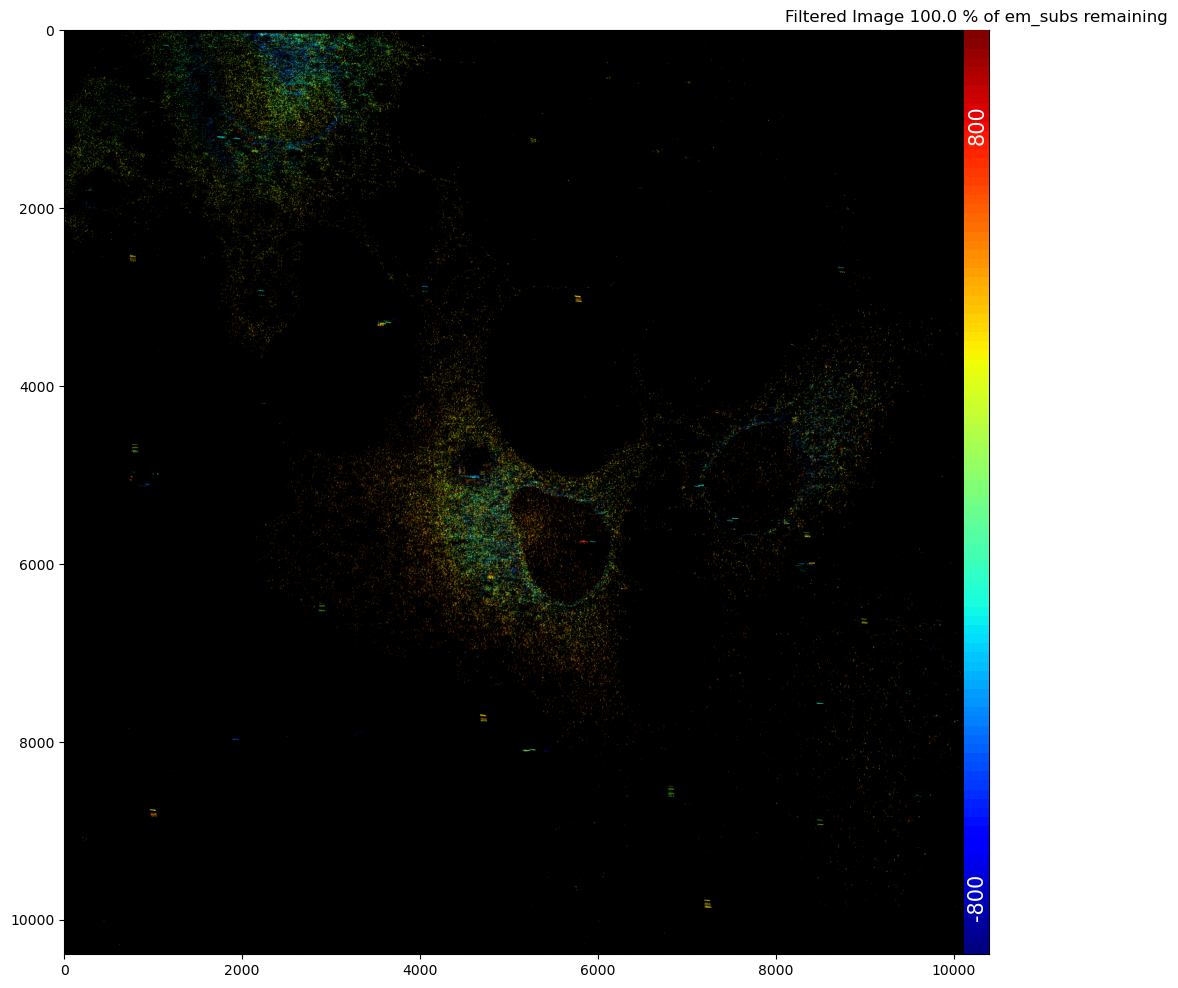

"\n# make figure for Z view\nplt.figure(figsize=(12, 3))\ndecode.renderer.Renderer2D(px_size=10., sigma_blur=5., rel_clip=None, abs_clip=50,\n                           zextent=[-800, 800], plot_axis=(0, 2)).render(em_sub)\nplt.savefig(os.path.join(fig_path, rf'rendered_filtered.png'), dpi=300, bbox_inches='tight')\nplt.show()\n"

In [72]:
sigma_x_high_threshold = 90
sigma_y_high_threshold = 90
sigma_z_high_threshold = 260
prob_threshold = 0.95

'''
em_sub = emitter[
    (emitter.xyz_sig_nm[:, 0] <= sigma_x_high_threshold)
    * (emitter.xyz_sig_nm[:, 1] <= sigma_x_high_threshold)
    * (emitter.xyz_sig_nm[:, 2] <= sigma_z_high_threshold)
    * (emitter.prob >= prob_threshold)
    ]
# em_sub = emitter.filter_by_sigma(0.67)  # alternatively
'''

em_sub = emitter

# make figure for XY view
plt.figure(figsize=(12, 12))
decode.renderer.Renderer2D(px_size=10., sigma_blur=5., rel_clip=None, abs_clip=.1,
                           zextent=[-800, 800], colextent=[-800, 800], plot_axis=(0, 1),
                           contrast=1.5).render(em_sub, em_sub.xyz_nm[:, 2])
plt.title(f'Filtered Image {np.round(100 * len(em_sub) / len(emitter))} % of em_subs remaining', loc='center')
plt.show()

'''
# make figure for Z view
plt.figure(figsize=(12, 3))
decode.renderer.Renderer2D(px_size=10., sigma_blur=5., rel_clip=None, abs_clip=50,
                           zextent=[-800, 800], plot_axis=(0, 2)).render(em_sub)
plt.savefig(os.path.join(fig_path, rf'rendered_filtered.png'), dpi=300, bbox_inches='tight')
plt.show()
'''

Instead of removing localizations you can also plot all of them and account for their uncertainty by rendering every localization as a Gaussian with a two dimensional standard deviation equal to the predicted uncertainty.
Below we compare plotting with a constant sigma blur, and with individually rendered Gaussians. The second option removes artifacts and correctly blurs out of focus structures.

More advanced plotting routines are for example available in the SMAP package (https://github.com/jries/SMAP)

c:\users\bnort\work\janelia_slm\code\decode\decode\renderer\renderer.py:351: UserWarning: __floordiv__ is deprecated, and its behavior will change in a future version of pytorch. It currently rounds toward 0 (like the 'trunc' function NOT 'floor'). This results in incorrect rounding for negative values. To keep the current behavior, use torch.div(a, b, rounding_mode='trunc'), or for actual floor division, use torch.div(a, b, rounding_mode='floor').
  w = int((x_hist_ext[1] - x_hist_ext[0]) // self.px_size + 1)
c:\users\bnort\work\janelia_slm\code\decode\decode\renderer\renderer.py:352: UserWarning: __floordiv__ is deprecated, and its behavior will change in a future version of pytorch. It currently rounds toward 0 (like the 'trunc' function NOT 'floor'). This results in incorrect rounding for negative values. To keep the current behavior, use torch.div(a, b, rounding_mode='trunc'), or for actual floor division, use torch.div(a, b, rounding_mode='floor').
  h = int((y_hist_ext[1] - y_hi

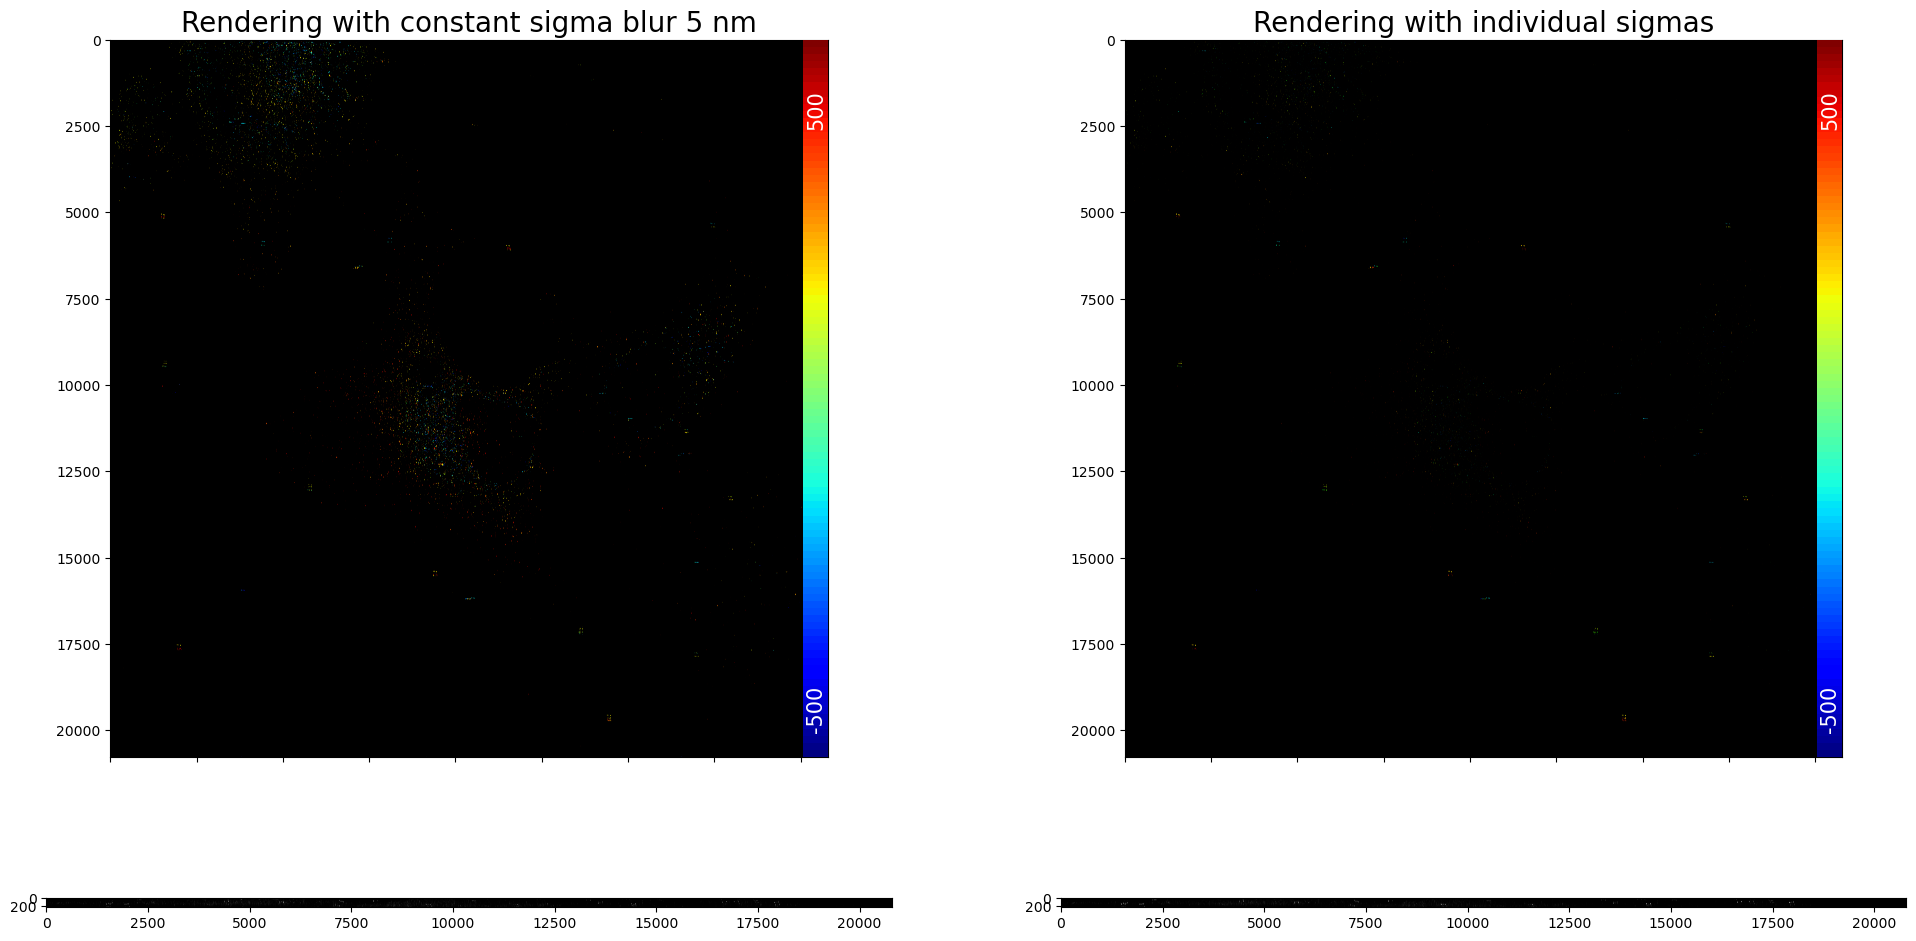

In [63]:
fig, axs = plt.subplots(2, 2, figsize=(24, 12), sharex='col',
                        gridspec_kw={'height_ratios': [1, 1200 / 7000]})
extents = {
    #'xextent': [14000, 22000],
    #'yextent': [1000, 8000],
    'zextent': [-600, 600],
    'colextent': [-500, 500]
}

decode.renderer.Renderer2D(
    px_size=5., sigma_blur=5., rel_clip=None, abs_clip=3, **extents,
    plot_axis=(0, 1), contrast=30).render(emitter, emitter.xyz_nm[:, 2], ax=axs[0, 0])

decode.renderer.Renderer2D(
    px_size=5., sigma_blur=5., rel_clip=None, abs_clip=15, **extents,
    plot_axis=(0, 2), contrast=2).render(emitter, ax=axs[1, 0])

decode.renderer.RendererIndividual2D(
    px_size=5., filt_size=20, rel_clip=None, abs_clip=3, **extents,
    plot_axis=(0, 1), contrast=3).render(emitter, emitter.xyz_nm[:, 2], ax=axs[0, 1])

decode.renderer.RendererIndividual2D(
    px_size=5., filt_size=20, rel_clip=None, abs_clip=3, **extents,
    plot_axis=(0, 2)).render(emitter, ax=axs[1, 1])

axs[0, 0].set_title('Rendering with constant sigma blur 5 nm', fontsize=20)
axs[0, 1].set_title('Rendering with individual sigmas', fontsize=20)


plt.show()

We can also get the rendered image as a numpy array then save it or send to Napari.

First filter the data and define some extents. 

In [30]:
sigma_x_high_threshold = 500
sigma_y_high_threshold = 500
sigma_z_high_threshold = 1000
prob_threshold = 0.1
bg_trheshold = 10

em_sub = emitter[
    (emitter.xyz_sig_nm[:, 0] <= sigma_x_high_threshold)
    * (emitter.xyz_sig_nm[:, 1] <= sigma_x_high_threshold)
    * (emitter.xyz_sig_nm[:, 2] <= sigma_z_high_threshold)
    * (emitter.prob >= prob_threshold)
    #* (emitter.bg >= bg_trheshold)
    ]
#
extents = {
    'xextent': [0, frames[0].shape[0]*130],
    'yextent': [0, frames[0].shape[1]*130],
    'zextent': [-1000, 1000],
    'colextent': [-1000, 1000]
}

Now assign the renderer to a variable, and call the ```forward``` and ```numpy``` functions to get an np arry

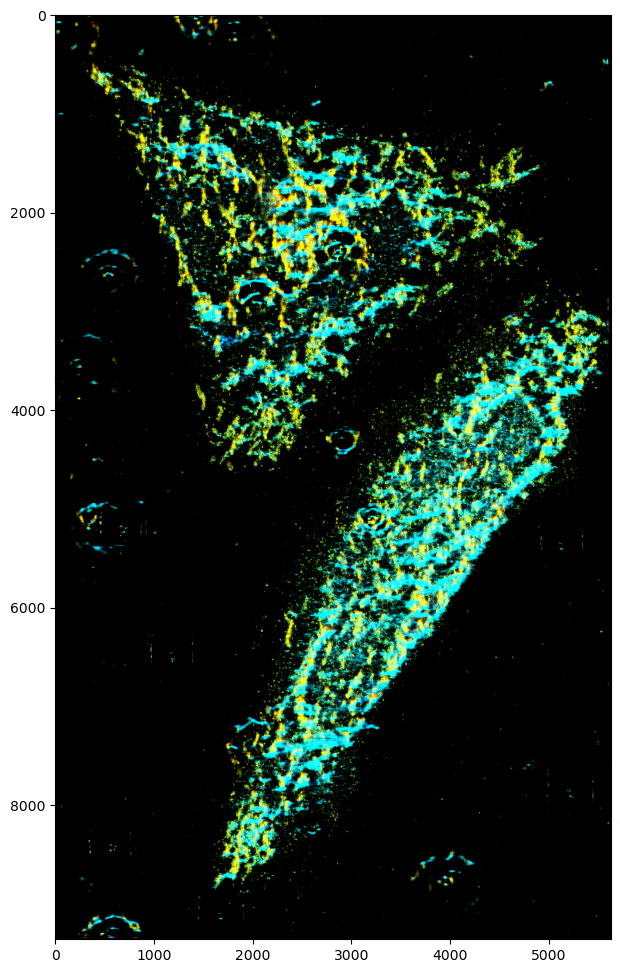

In [31]:


renderer = decode.renderer.Renderer2D(px_size=10., sigma_blur=5, rel_clip=None, abs_clip=50, 
                           **extents, plot_axis=(0, 1),
                           contrast=100.25)#.render(emitter, emitter.xyz_nm[:, 2], ax=axs[0, 0])

rendered = renderer.forward(em_sub, em_sub.xyz_nm[:, 2])
rendered = rendered.numpy()
rendered = np.transpose(rendered, (1, 0, 2))

# todo... why is image reversed when rendering this way...
#rendered = rendered[::-1, :, :]

plt.figure(figsize=(12, 12))
plt.imshow(rendered)

In [45]:
rendered.dtype, rendered.shape, rendered.min(), rendered.max()

rendered8bit = (rendered*255).astype(np.uint8)

imsave(os.path.join(fig_path, rf'fitting\rendered.png'), rendered8bit)

In [32]:
from skimage.io import imsave
imsave(os.path.join(fig_path, rf'fitting\rendered.png'), rendered)

TypeError: Cannot handle this data type: (1, 1, 3), <f8

In [ ]:
import napari

viewer = napari.Viewer()
viewer.add_image(rendered, name='rendered')

<Image layer 'rendered' at 0x203a32c65e0>

: 

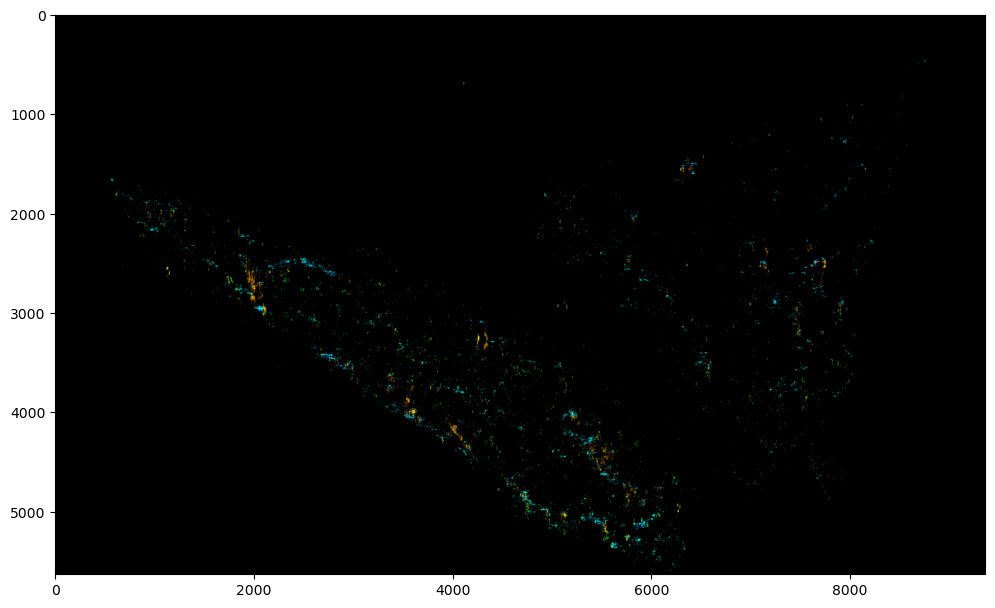

In [ ]:

plt.figure(figsize=(12, 12))
plt.imshow(rendered2)

In [29]:
from skimage.io import imsave
print(rendered.shape)
out_name = os.path.join(out_path, model_name+'_filtered_rendered.tif')
print(out_name)
imsave(out_name, rendered)
# (5629, 9360, 3

(5629, 9360, 3)
D:\Janelia_slm\PALM Acquisition 50Gb (depleted frames ie low density stochastic emitters)\crop1\out\network_CMOS_C13440_20CUc_filtered_rendered.tif


C:\Users\bnort\AppData\Local\Temp\ipykernel_32760\1071532271.py:5: UserWarning: D:\Janelia_slm\PALM Acquisition 50Gb (depleted frames ie low density stochastic emitters)\crop1\out\network_CMOS_C13440_20CUc_filtered_rendered.tif is a low contrast image
  imsave(out_name, rendered)


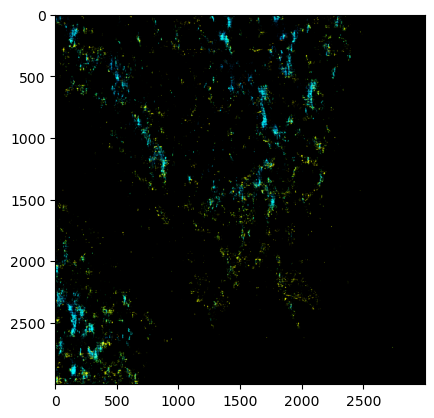

In [26]:
plt.imshow(rendered[2000:5000,5000:8000,:])

In [17]:
# to numpy 
rendered = rendered.numpy()
rendered = rendered[:,::-1]

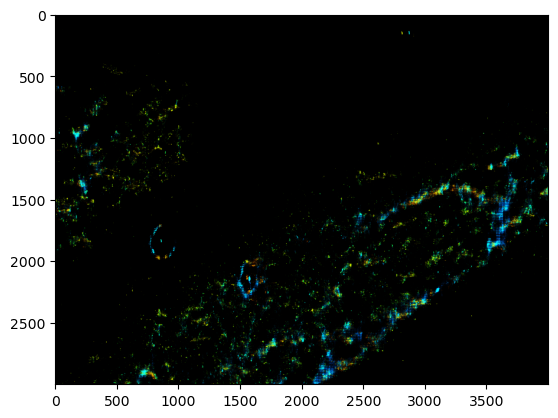

In [11]:
renderer = decode.renderer.Renderer2D(px_size=10., sigma_blur=5, rel_clip=None, abs_clip=50, xextent = [10000,40000], yextent = [30000, 70000],
                           zextent=[-1000, 1000], colextent=[-1000, 1000], plot_axis=(0, 1),
                           contrast=10.25)#.render(emitter, emitter.xyz_nm[:, 2], ax=axs[0, 0])

rendered = renderer.forward(emitter, emitter.xyz_nm[:, 2])

plt.imshow(rendered)

In [ ]:
renderer = decode.renderer.Renderer2D(px_size=10., sigma_blur=5, rel_clip=None, abs_clip=50,
                           zextent=[-1000, 1000], colextent=[-1000, 1000], plot_axis=(0, 1),
                           contrast=1.25)#.render(emitter, emitter.xyz_nm[:, 2], ax=axs[0, 0])

rendered = renderer.forward(em_sub, em_sub.xyz_nm[:, 2])


# to numpy

rendered_np = rendered.cpu().numpy()

from skimage.io import imsave
print(rendered_np.dtype)
# to uint8
rendered_np_8bit = (rendered_np / rendered_np.max() * 255).astype('uint8')
#emitters_sub_name = os.path.join(frame_path, 'emitter_sub.tif')
imsave(emitters_sub_name, rendered_np_8bit)

plt.imshow(rgb[2*2400:2*2700, 2*3800:2*4200,:])

rgb = rgb.astype('float32')
imsave(out_name, rgb)

rgb_8bit = (rgb * 255).astype('uint8')
imsave(os.path.join(frame_path, 'rendered8bit.tif'), rgb_8bit)

# convert test to numpy
rgb = test.cpu().numpy()
# move channel axis to first
#test = np.moveaxis(test, -1, 0)

plt.imshow(rgb)

from skimage.io import imsave

out_name = os.path.join(frame_path, 'rendered.tif')

#imsave(out_name, rgb)

#import napari